# Review 1 — Gaussian Naive Bayes

**Track:** Classification Part-A

**Dataset:** UCI Bank Marketing (`bank-full.csv`)

**Problem:** Predict whether the client subscribed to a term deposit (`y = yes/no`).

## 1. Imports and Dataset Audit

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name != "Review-1" and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from classification_preprocessing import load_bank_dataset, prepare_features_target, build_preprocessor

DATA_PATH = PROJECT_ROOT / "data" / "bank-full.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42


In [2]:
df = load_bank_dataset(DATA_PATH)
print("Dataset shape:", df.shape)
display(df.head())
display(df.dtypes.to_frame("dtype"))
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))
print("Duplicate rows:", df.duplicated().sum())
display(df["y"].value_counts().to_frame("count"))


Dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


,dtype
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


,missing_count
poutcome,36959
contact,13020
education,1857
job,288
age,0
default,0
balance,0
housing,0
marital,0
loan,0


Duplicate rows: 0


,count
y,
no,39922
yes,5289


### Duplicate-record decision

The dataset has no unique customer identifier. Therefore, identical feature rows are not automatically proof that they represent the same customer. Duplicate-looking records are retained unless there is independent evidence that they are erroneous. This avoids blindly deleting legitimate observations.

## 2. Exploratory Data Analysis

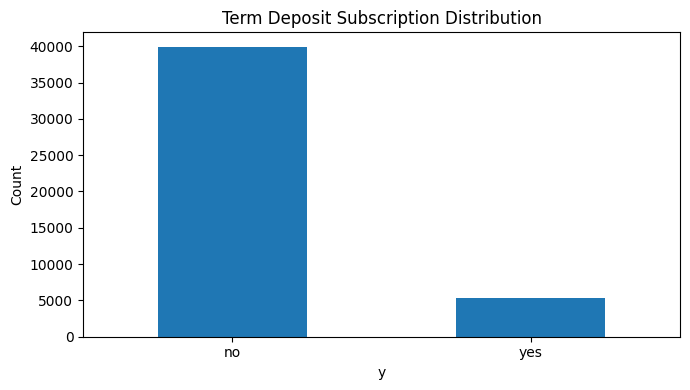

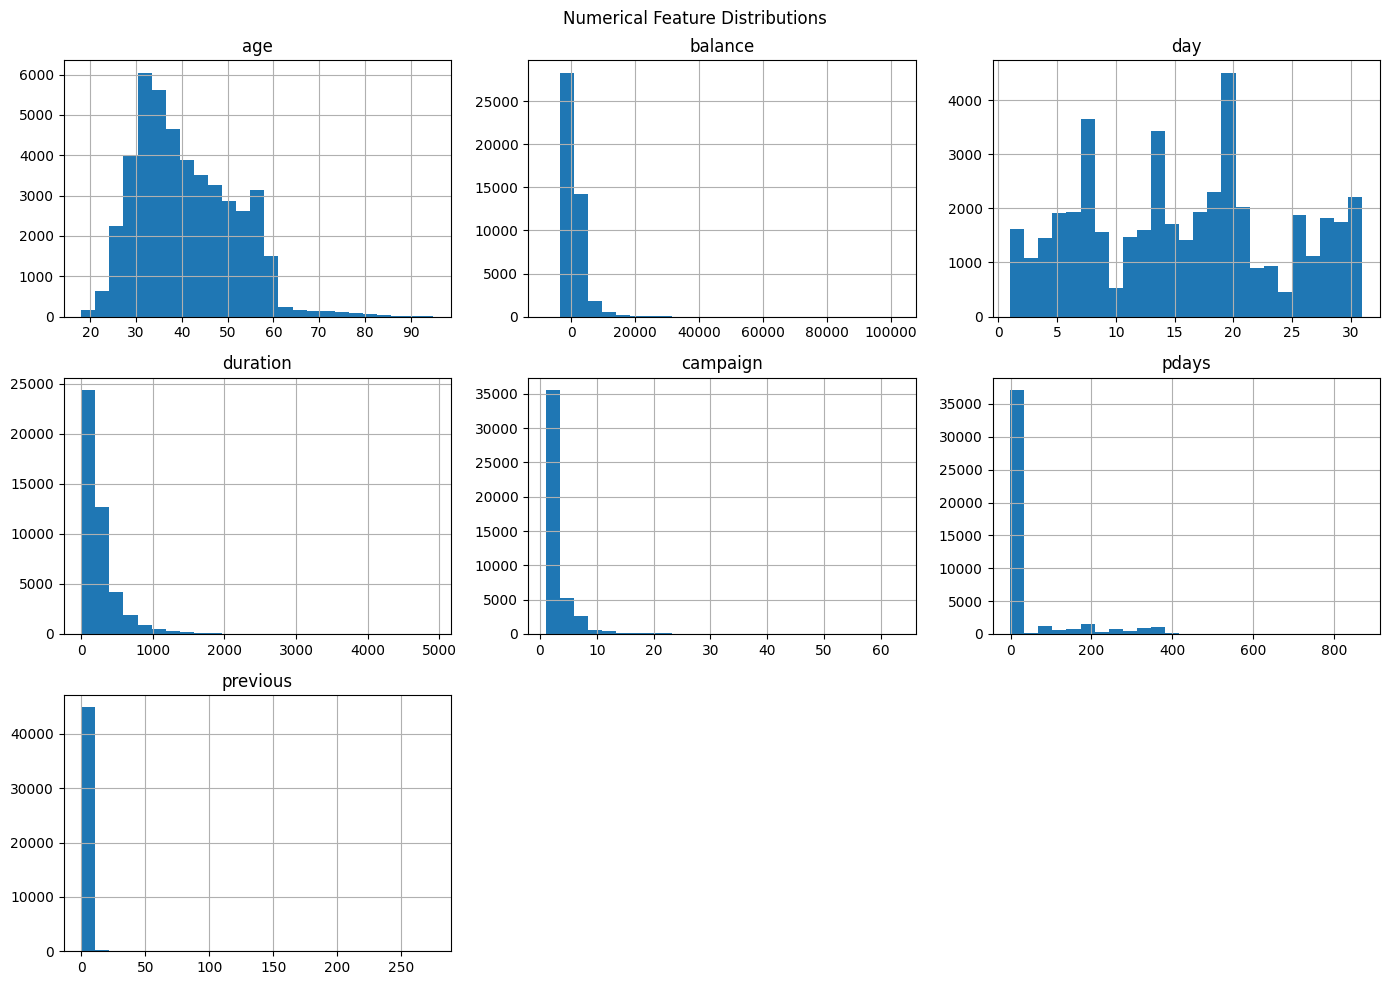

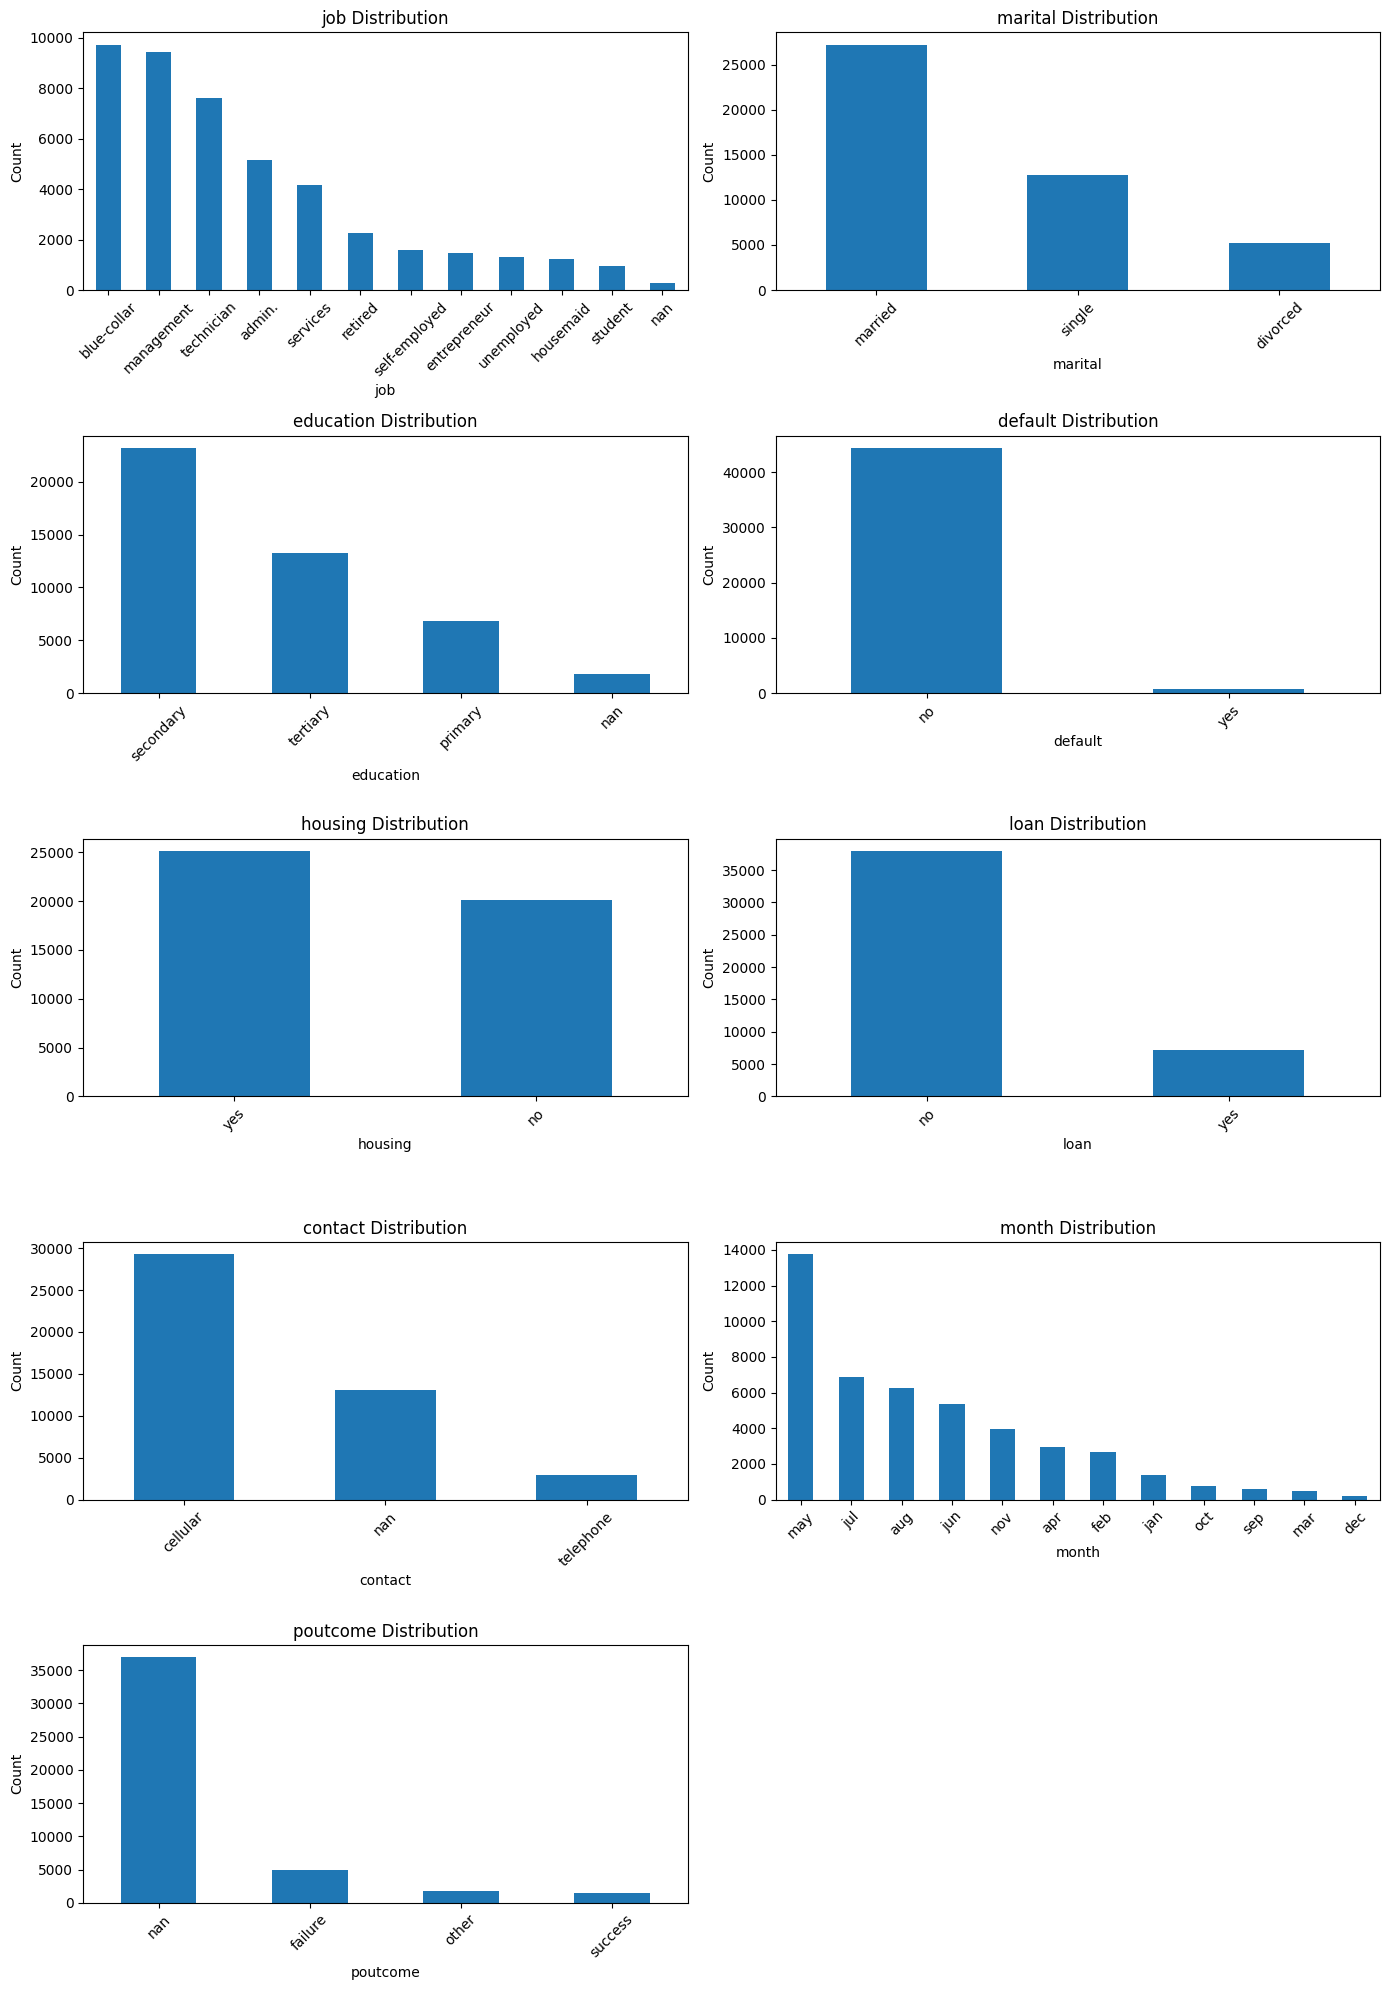

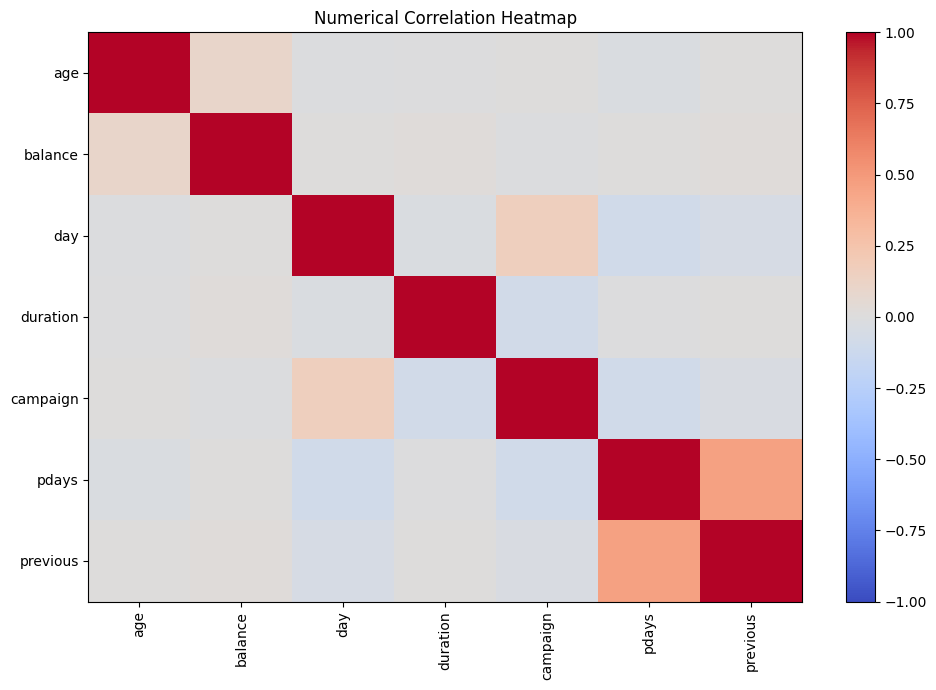

In [3]:
# Target distribution
fig, ax = plt.subplots(figsize=(7,4))
df["y"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_title("Term Deposit Subscription Distribution")
ax.set_xlabel("y")
ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

# Numerical feature distributions
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].hist(figsize=(14,10), bins=25)
plt.suptitle("Numerical Feature Distributions")
plt.tight_layout(); plt.show()

# Categorical feature distributions
cat_cols = df.select_dtypes(exclude=np.number).columns.drop("y")
ncols = 2
nrows = int(np.ceil(len(cat_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows))
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, cat_cols):
    df[col].value_counts(dropna=False).plot(kind="bar", ax=ax)
    ax.set_title(f"{col} Distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
for ax in axes[len(cat_cols):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

# Numerical correlation heatmap
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(10,7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.index))); ax.set_yticklabels(corr.index)
ax.set_title("Numerical Correlation Heatmap")
fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()


### Student Observation

**Target distribution:** Write 1–2 sentences here based on the actual target plot.

**Numerical distributions:** Write 1–2 sentences here based on the histograms.

**Categorical distributions:** Write 1–2 sentences here based on the important categorical bar charts.

**Correlation heatmap:** Write 1–2 sentences here based on the actual heatmap. Do not claim relationships that are not visible.

### Numerical outlier screening

In [4]:
X_num_audit = df.drop(columns=["y"]).select_dtypes(include=np.number)
q1 = X_num_audit.quantile(0.25)
q3 = X_num_audit.quantile(0.75)
iqr = q3 - q1
outlier_counts = ((X_num_audit < (q1 - 1.5*iqr)) | (X_num_audit > (q3 + 1.5*iqr))).sum().sort_values(ascending=False)
display(outlier_counts.to_frame("IQR_potential_outlier_count"))


,IQR_potential_outlier_count
previous,8257
pdays,8257
balance,4729
duration,3235
campaign,3064
age,487
day,0


### Outlier decision

IQR screening identifies potential extreme numerical values but does not establish that they are errors. No rows are removed solely because of an IQR flag. The values are retained because the Bank Marketing variables can legitimately have skewed/extreme observations, and the project does not have evidence that these records are erroneous.

**Student Observation:** Write 1–2 sentences here based on the actual outlier counts.

## 3. Prepare Data and Stratified Split

In [5]:
X, y = prepare_features_target(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train class proportions:")
display(y_train.value_counts(normalize=True).to_frame("proportion"))


Train: (36168, 16) Test: (9043, 16)
Train class proportions:


,proportion
y,
0,0.883018
1,0.116982


In [6]:
preprocessor = build_preprocessor(X_train, scale_numeric=True, dense=True)
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
pipe = Pipeline([("preprocess", preprocessor), ("model", model)])


## 4. Train and Evaluate

In [7]:
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

if hasattr(pipe, "predict_proba"):
    score = pipe.predict_proba(X_test)[:, 1]
else:
    score = pipe.decision_function(X_test)
roc_auc = roc_auc_score(y_test, score)

print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"Weighted F1    : {weighted_f1:.4f}")
print(f"ROC-AUC        : {roc_auc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["no", "yes"], zero_division=0))

result = {"model": 'Gaussian Naive Bayes', "accuracy": accuracy, "precision": precision, "recall": recall, "weighted_f1": weighted_f1, "roc_auc": roc_auc}
pd.DataFrame([result]).to_csv(RESULTS_DIR / '03_gaussian_naive_bayes_classification.csv', index=False)
joblib.dump(pipe, MODELS_DIR / '03_gaussian_naive_bayes_classification.joblib')
display(pd.DataFrame([result]))


Accuracy       : 0.8519
Precision      : 0.3946
Recall         : 0.4972
Weighted F1    : 0.8591
ROC-AUC        : 0.8021

Classification report:
              precision    recall  f1-score   support

          no       0.93      0.90      0.91      7985
         yes       0.39      0.50      0.44      1058

    accuracy                           0.85      9043
   macro avg       0.66      0.70      0.68      9043
weighted avg       0.87      0.85      0.86      9043



,model,accuracy,precision,recall,weighted_f1,roc_auc
0,Gaussian Naive Bayes,0.85193,0.394599,0.497164,0.859148,0.802065


## 5. Confusion Matrix

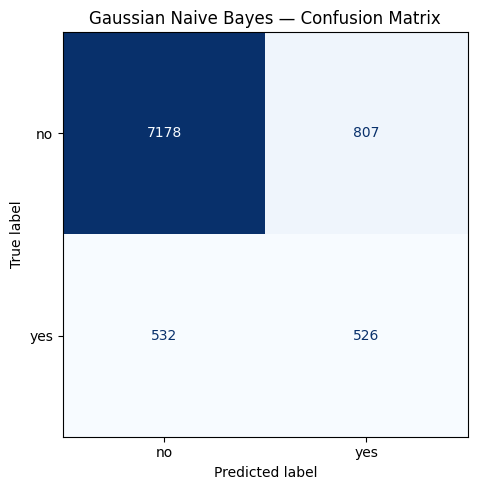

In [8]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no", "yes"])
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, values_format="d", cmap="Blues", colorbar=False)
ax.set_title(f"{'Gaussian Naive Bayes'} — Confusion Matrix")
plt.tight_layout(); plt.show()


Gaussian Naive Bayes requires a dense numeric matrix; one-hot categorical features are therefore converted to a dense matrix.